In [2]:
import os

REPO_NAME = "4803_project_advanced_neural_networks"
REPO_URL = "https://github.com/zarcop/4803_project_advanced_neural_networks"
if not os.path.isdir(REPO_NAME):
    !git clone {REPO_URL}
else:
    !git -C {REPO_NAME} pull

Already up to date.


Device: cuda


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.95MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.94MB/s]


=== LeNet-5 (420s) ===
=== AlexNet4803 (420s) ===

=== Comparison @ fixed wall time 420s ===


,Model,Params,GFLOPs / forward,Samples @ T=420s,Total GFLOPs,Train Acc (%),Val Acc (%),Val gap (Train−Val) (%),Efficiency (ValAcc / Total GFLOPs),Gen. eff. ((2·Val−Train) / Total GFLOPs)
0,LeNet-5,61706,0.000838,846784,7.094289e+02,99.866667,98.92,0.946667,0.139436,0.138102
1,AlexNet4803,57759562,1.998261,1153312,2.304618e+06,99.856667,99.25,0.606667,0.000043,0.000043


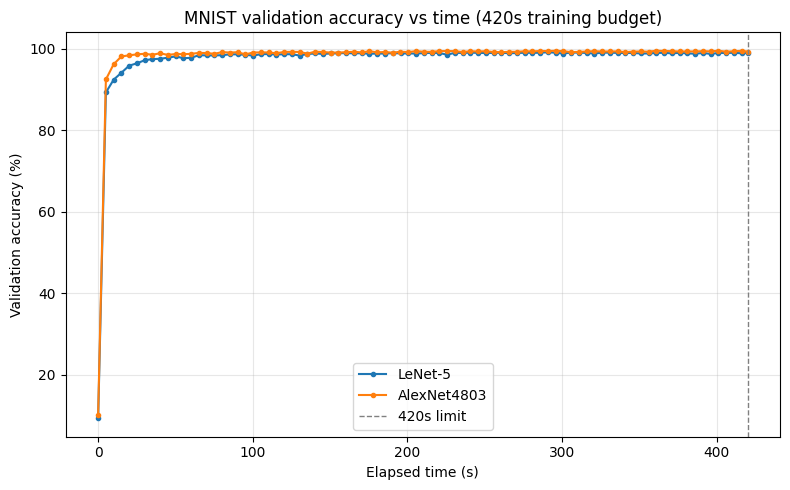

In [ ]:
# --- Optional: FLOP estimation (MACs -> GFLOPs via ×2) ---
try:
    from thop import profile as thop_profile
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "thop", "-q"])
    from thop import profile as thop_profile

import importlib.util
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:

    def display(obj):
        print(obj.to_string() if hasattr(obj, "to_string") else obj)
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Repo / model imports (works if cwd is repo root or model/)
_here = Path.cwd().resolve()
if (_here / "le_net_5.py").exists():
    MODEL_DIR = _here
elif (_here / "model" / "le_net_5.py").exists():
    MODEL_DIR = _here / "model"
else:
    MODEL_DIR = Path("/content/4803_project_advanced_neural_networks/model")
    if not MODEL_DIR.exists():
        raise FileNotFoundError(f"Cannot find model dir; cwd={_here}")

if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))

spec_l = importlib.util.spec_from_file_location("le_net_5", MODEL_DIR / "le_net_5.py")
mod_l = importlib.util.module_from_spec(spec_l)
spec_l.loader.exec_module(mod_l)
LeNet5 = mod_l.LeNet5

spec_a = importlib.util.spec_from_file_location("alexnet", MODEL_DIR / "alexnet.py")
mod_a = importlib.util.module_from_spec(spec_a)
spec_a.loader.exec_module(mod_a)
AlexNet4803 = mod_a.AlexNet4803

# Reproducibility and device setup
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

TIME_LIMIT = 420.0
BATCH_SIZE = 128
VAL_EVERY_SEC = 5.0  # validation checkpoints for plotting

# Best settings from the MNIST validation notebooks
LENET_LR = 1e-3
LENET_DROPOUT = 0.0
ALEX_LR = 1e-3
ALEX_K1, ALEX_S1, ALEX_P1 = 3, 1, 1

# MNIST preprocessing (LeNet uses normalization; AlexNet uses 64x64 tensors)
MNIST_MEAN = (0.1307,)
MNIST_STD = (0.3081,)

lenet_transform = transforms.Compose(
    [
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize(MNIST_MEAN, MNIST_STD),
    ]
)

alex_transform = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ]
)

train_lenet = datasets.MNIST(root="./data", train=True, download=True, transform=lenet_transform)
test_lenet = datasets.MNIST(root="./data", train=False, download=True, transform=lenet_transform)
train_alex = datasets.MNIST(root="./data", train=True, download=True, transform=alex_transform)
test_alex = datasets.MNIST(root="./data", train=False, download=True, transform=alex_transform)

train_loader_lenet = DataLoader(train_lenet, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_lenet = DataLoader(test_lenet, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
train_loader_alex = DataLoader(train_alex, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_alex = DataLoader(test_alex, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


def evaluate_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            logits = model(inputs)
            pred = logits.argmax(dim=1)
            total += targets.size(0)
            correct += (pred == targets).sum().item()
    return 100.0 * correct / total


def count_params(model):
    return sum(p.numel() for p in model.parameters())


def gflops_per_forward(model, device, c, h, w):
    model.eval()
    dummy = torch.randn(1, c, h, w, device=device)
    try:
        macs, _ = thop_profile(model, inputs=(dummy,), verbose=False)
    except Exception as exc:
        print(f"thop FLOP estimate failed ({exc}); GFLOP-based metrics will be NaN.")
        return float("nan")
    gflops = float(macs) * 2.0 / 1e9
    return gflops


def train_with_bottleneck(model, train_loader, optimizer, criterion, device, time_limit=420):
    """Fixed-time training loop (spec). Stops mid-batch if the limit is reached before forward."""
    start_time = time.time()
    total_samples_processed = 0
    model.train()

    while (time.time() - start_time) < time_limit:
        for inputs, targets in train_loader:
            elapsed = time.time() - start_time
            if elapsed >= time_limit:
                return model, total_samples_processed

            optimizer.zero_grad()
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            total_samples_processed += inputs.size(0)
    return model, total_samples_processed


def train_with_bottleneck_val_curve(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    time_limit=420,
    val_every_sec=5.0,
):
    """
    Same stopping rule as train_with_bottleneck, plus periodic validation for plotting.
    Wall-clock includes validation time.
    """
    start_time = time.time()
    total_samples_processed = 0
    model.train()
    val_times = []
    val_accs = []
    last_val_elapsed = -1e9

    def maybe_validate():
        nonlocal last_val_elapsed
        elapsed = time.time() - start_time
        if elapsed >= time_limit:
            return False
        if elapsed - last_val_elapsed < val_every_sec:
            return True
        last_val_elapsed = elapsed
        acc = evaluate_accuracy(model, val_loader, device)
        val_times.append(elapsed)
        val_accs.append(acc)
        model.train()
        return True

    while (time.time() - start_time) < time_limit:
        for inputs, targets in train_loader:
            elapsed = time.time() - start_time
            if elapsed >= time_limit:
                return model, total_samples_processed, val_times, val_accs

            maybe_validate()
            if (time.time() - start_time) >= time_limit:
                return model, total_samples_processed, val_times, val_accs

            optimizer.zero_grad()
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            total_samples_processed += inputs.size(0)

    return model, total_samples_processed, val_times, val_accs


def run_benchmark(name, build_model, train_loader, val_loader, lr):
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    model = build_model().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    c, h, w = (1, 32, 32) if name == "LeNet-5" else (1, 64, 64)
    gf_per = gflops_per_forward(model, device, c, h, w)
    n_params = count_params(model)

    t0 = time.time()
    model, n_samples, val_t, val_a = train_with_bottleneck_val_curve(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        device,
        time_limit=TIME_LIMIT,
        val_every_sec=VAL_EVERY_SEC,
    )
    wall = time.time() - t0

    train_acc = evaluate_accuracy(model, train_loader, device)
    val_acc = evaluate_accuracy(model, val_loader, device)
    val_t, val_a = list(val_t), list(val_a)
    end_t = min(TIME_LIMIT, wall)
    if not val_t or abs(val_t[-1] - end_t) > 0.25:
        val_t.append(end_t)
        val_a.append(val_acc)
    val_gap = train_acc - val_acc

    total_gflops = gf_per * n_samples
    eff = val_acc / total_gflops if total_gflops > 0 else float("nan")
    gen_eff = (val_acc - val_gap) / total_gflops if total_gflops > 0 else float("nan")

    return {
        "model": name,
        "params": n_params,
        "gflops_per_forward": gf_per,
        "samples_processed": n_samples,
        "total_gflops_expended": total_gflops,
        "train_acc_pct": train_acc,
        "val_acc_pct": val_acc,
        "val_gap_pct": val_gap,
        "efficiency_ratio": eff,
        "generalization_efficiency_ratio": gen_eff,
        "wall_clock_s": wall,
        "val_curve_t": val_t,
        "val_curve_acc": val_a,
    }


print("=== LeNet-5 (420s) ===")
res_lenet = run_benchmark(
    "LeNet-5",
    lambda: LeNet5(in_channels=1, k_classes=10, dropout=LENET_DROPOUT),
    train_loader_lenet,
    val_loader_lenet,
    LENET_LR,
)

print("=== AlexNet4803 (420s) ===")
res_alex = run_benchmark(
    "AlexNet4803",
    lambda: AlexNet4803(1, 10, k1=ALEX_K1, s1=ALEX_S1, p1=ALEX_P1),
    train_loader_alex,
    val_loader_alex,
    ALEX_LR,
)

table = pd.DataFrame(
    [
        {
            "Model": res_lenet["model"],
            "Params": res_lenet["params"],
            "GFLOPs / forward": res_lenet["gflops_per_forward"],
            "Samples @ T=420s": res_lenet["samples_processed"],
            "Total GFLOPs": res_lenet["total_gflops_expended"],
            "Train Acc (%)": res_lenet["train_acc_pct"],
            "Val Acc (%)": res_lenet["val_acc_pct"],
            "Val gap (Train−Val) (%)": res_lenet["val_gap_pct"],
            "Efficiency (ValAcc / Total GFLOPs)": res_lenet["efficiency_ratio"],
            "Gen. eff. ((2·Val−Train) / Total GFLOPs)": res_lenet["generalization_efficiency_ratio"],
        },
        {
            "Model": res_alex["model"],
            "Params": res_alex["params"],
            "GFLOPs / forward": res_alex["gflops_per_forward"],
            "Samples @ T=420s": res_alex["samples_processed"],
            "Total GFLOPs": res_alex["total_gflops_expended"],
            "Train Acc (%)": res_alex["train_acc_pct"],
            "Val Acc (%)": res_alex["val_acc_pct"],
            "Val gap (Train−Val) (%)": res_alex["val_gap_pct"],
            "Efficiency (ValAcc / Total GFLOPs)": res_alex["efficiency_ratio"],
            "Gen. eff. ((2·Val−Train) / Total GFLOPs)": res_alex["generalization_efficiency_ratio"],
        },
    ]
)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print("\n=== Comparison @ fixed wall time 420s ===")
display(table)

plt.figure(figsize=(8, 5))
plt.plot(res_lenet["val_curve_t"], res_lenet["val_curve_acc"], label="LeNet-5", marker="o", markersize=3)
plt.plot(res_alex["val_curve_t"], res_alex["val_curve_acc"], label="AlexNet4803", marker="o", markersize=3)
plt.xlabel("Elapsed time (s)")
plt.ylabel("Validation accuracy (%)")
plt.title("MNIST validation accuracy vs time (420s training budget)")
plt.axvline(TIME_LIMIT, color="gray", linestyle="--", linewidth=1, label="420s limit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
